# Sensitivity Analysis — A123 DFN — V vs Time
**1C cycle** (Dis 2.5V → Chg 3.6V → CV 10mA) and **2C cycle** (Dis 2V → Chg 3.6V → CV 10mA)
Each parameter varied ×0.5, 0.8, 1.0, 1.2, 1.5, 2.0 — plotted against experimental data.

In [14]:
import pybamm as pb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import style
import warnings, time as _time
warnings.filterwarnings('ignore')
style.use("ggplot")
print(f"PyBaMM {pb.__version__}")

PyBaMM 25.8.0


## 1. Model, OCP data, experimental data

In [15]:
model = pb.lithium_ion.DFN({
    "particle phases": ("1", "1"),
    "open-circuit potential": ("current sigmoid", "current sigmoid"),
    "cell geometry": "arbitrary",
    "intercalation kinetics": "symmetric Butler-Volmer",
    "diffusivity": "single",
    "thermal": "lumped",
    "contact resistance": "true",
})

# OCP arrays
df_lfp_  = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='LFP_Lithiation')
df_Gr_   = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='Gr_Delithiation')
df_lfp_1 = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='LFP_Delithiation')
df_Gr_1  = pd.read_excel('OCP_Interpolated_Prada2012.xlsx', sheet_name='Gr_Lithiation')
neg_array, pos_array = df_Gr_.to_numpy(), df_lfp_.to_numpy()
neg_array_1, pos_array_1 = df_Gr_1.to_numpy(), df_lfp_1.to_numpy()

# Experimental data — load once
exp = {}
for sheet in ['ocv','1D','1C','2D','2C','3C','4C']:
    try:
        exp[sheet] = pd.read_excel('A123_data.xlsx', sheet_name=sheet)
    except:
        pass
print(f"Exp sheets loaded: {list(exp.keys())}")

Exp sheets loaded: ['ocv', '1D', '1C', '2D', '2C', '3C', '4C']


## 2. Function factories

In [16]:
def make_neg_j0(m_ref=6.48e-05, E_r=35000.0):
    def j0(c_e, c_s_surf, c_s_max, T):
        return m_ref * np.exp(E_r/pb.constants.R*(1/298.15-1/T)) * c_e**0.5 * c_s_surf**0.5 * (c_s_max-c_s_surf)**0.5
    return j0

def make_pos_j0(m_ref=6e-07, E_r=39570.0):
    def j0(c_e, c_s_surf, c_s_max, T):
        return m_ref * np.exp(E_r/pb.constants.R*(1/298.15-1/T)) * c_e**0.5 * c_s_surf**0.5 * (c_s_max-c_s_surf)**0.5
    return j0

def make_pos_Ds(D_ref=1.35e-17, E_D=39000.0):
    def Ds(sto, T):
        return D_ref * np.exp(E_D/pb.constants.R*(1/298.15-1/T))
    return Ds

def make_neg_Ds(D_ref=2.4e-13, E_D=35000.0):
    def Ds(sto, T):
        return D_ref * np.exp(E_D/pb.constants.R*(1/298.15-1/T))
    return Ds

def make_elyte_cond(scale=1.0, E_k=2.7771e4):
    def sigma(c_e, T):
        cm = 1e-3*c_e
        s296 = 0.2667*cm**3 - 1.2983*cm**2 + 1.7919*cm + 0.1726
        C = 296*np.exp(E_k/(pb.constants.R*296))
        return scale * C * s296 * np.exp(-E_k/(pb.constants.R*T)) / T
    return sigma

def elyte_diffusivity(c_e, T):
    inputs = {"Electrolyte concentration [mol.m-3]": c_e, "Temperature [K]": T}
    sigma_e = pb.FunctionParameter("Electrolyte conductivity [S.m-1]", inputs)
    return (pb.constants.k_b/(pb.constants.F*pb.constants.q_e)) * sigma_e * T / c_e

def make_lfp_ocp(v0=3.4297, c1=-150, c2=-30):
    def ocp(sto):
        return v0 - 0.020269*sto + 0.5*np.exp(c1*sto) - 0.9*np.exp(c2*(1-sto))
    return ocp

def make_lfp_ocp_lith(v0=3.4097, c1=-150, c2=-30):
    def ocp(sto):
        return v0 - 0.020269*sto + 0.5*np.exp(c1*sto) - 0.9*np.exp(c2*(1-sto))
    return ocp

print("Factories ready.")

Factories ready.


## 3. Baseline parameters

In [18]:
def build_baseline():
    return {
        "Negative current collector thickness [m]": 2*7.44e-05,
        "Negative electrode thickness [m]": 3.63e-05,
        "Separator thickness [m]": 2.5e-05,
        "Positive electrode thickness [m]": 6.27e-05,
        "Positive current collector thickness [m]": 2*5.75e-05,
        "Electrode height [m]": 1.714,
        "Electrode width [m]": 2*0.055,
        "Cell cooling surface area [m2]": 2.14e-3,
        "Cell volume [m3]": 3.38e-5,
        "Cell thermal expansion coefficient [m.K-1]": 1.1e-06,
        "Negative current collector conductivity [S.m-1]": 0.75*58411000.0,
        "Positive current collector conductivity [S.m-1]": 0.75*36914000.0,
        "Negative current collector density [kg.m-3]": 8960.0,
        "Positive current collector density [kg.m-3]": 2700.0,
        "Negative current collector specific heat capacity [J.kg-1.K-1]": 385.0,
        "Positive current collector specific heat capacity [J.kg-1.K-1]": 897.0,
        "Negative current collector thermal conductivity [W.m-1.K-1]": 401.0,
        "Positive current collector thermal conductivity [W.m-1.K-1]": 237.0,
        "Nominal cell capacity [A.h]": 2.5,
        "Current function [A]": 2.5,
        "Contact resistance [Ohm]": 0.01,
        "Positive particle delithiation hysteresis decay rate": 50,
        "Positive particle lithiation hysteresis decay rate": 50,
        "Initial hysteresis state in positive electrode": 1,
        # Negative
        "Maximum concentration in negative electrode [mol.m-3]": 30985,
        "Initial concentration in negative electrode [mol.m-3]": 0.76*30985,
        "Negative electrode exchange-current density [A.m-2]": make_neg_j0(),
        "Negative electrode delithiation OCP [V]": ("neg_deli", neg_array),
        "Negative electrode lithiation OCP [V]": ("neg_lith", neg_array_1),
        "Negative electrode OCP [V]": ("neg_ocp", (neg_array+neg_array_1)/2),
        "Negative particle radius [m]": 3e-07,
        "Negative particle diffusivity [m2.s-1]": make_neg_Ds(),
        "Negative electrode active material volume fraction": 0.58,
        "Negative electrode porosity": 0.32,
        "Negative electrode Bruggeman coefficient (electrolyte)": 2.5,
        "Negative electrode Bruggeman coefficient (electrode)": 1.5,
        "Negative electrode conductivity [S.m-1]": 0.5*215.0,
        "Negative electrode density [kg.m-3]": 2260,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 700.0,
        "Negative electrode thermal conductivity [W.m-1.K-1]": 1.7,
        "Negative electrode OCP entropic change [V.K-1]": 0.0,
        # Positive
        "Positive electrode lithiation OCP [V]": make_lfp_ocp_lith(),
        "Positive electrode delithiation OCP [V]": ("pos_deli", pos_array_1),
        "Positive electrode OCP [V]": make_lfp_ocp(),
        "Maximum concentration in positive electrode [mol.m-3]": 22806,
        "Initial concentration in positive electrode [mol.m-3]": 0.01*22882,
        "Positive particle diffusivity [m2.s-1]": make_pos_Ds(),
        "Positive particle radius [m]": 0.75*3.80e-08,
        "Positive electrode conductivity [S.m-1]": 0.8,
        "Positive electrode active material volume fraction": 0.370529,
        "Positive electrode porosity": 0.55,
        "Positive electrode Bruggeman coefficient (electrolyte)": 2.5,
        "Positive electrode Bruggeman coefficient (electrode)": 1.5,
        "Positive electrode exchange-current density [A.m-2]": make_pos_j0(),
        "Positive electrode density [kg.m-3]": 3610,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1000.0,
        "Positive electrode thermal conductivity [W.m-1.K-1]": 2.1,
        "Positive electrode OCP entropic change [V.K-1]": 0.0,
        # Separator
        "Separator porosity": 0.55,
        "Separator Bruggeman coefficient (electrolyte)": 2.5,
        "Separator density [kg.m-3]": 397.0,
        "Separator specific heat capacity [J.kg-1.K-1]": 900.0,
        "Separator thermal conductivity [W.m-1.K-1]": 0.16,
        # Electrolyte
        "Initial concentration in electrolyte [mol.m-3]": 1200.0,
        "Cation transference number": 0.38,
        "Thermodynamic factor": 0.5,
        "Electrolyte diffusivity [m2.s-1]": elyte_diffusivity,
        "Electrolyte conductivity [S.m-1]": make_elyte_cond(),
        # Conditions
        "Reference temperature [K]": 298.15,
        "Total heat transfer coefficient [W.m-2.K-1]": 12.0,
        "Ambient temperature [K]": 298.15,
        "Number of electrodes connected in parallel to make a cell": 1.0,
        "Number of cells connected in series to make a battery": 1.0,
        "Lower voltage cut-off [V]": 2,
        "Upper voltage cut-off [V]": 3.65,
        "Open-circuit voltage at 0% SOC [V]": 2,
        "Open-circuit voltage at 100% SOC [V]": 3.65,
        "Initial temperature [K]": 298.15,
    }
print("Baseline builder ready.")

Baseline builder ready.


## 4. MSMR graphite OCP update & simulation runner

In [19]:
# MSMR graphite
F_c, R_c, T_r = 96485.33212, 8.314462618, 298.15
f_v = F_c/(R_c*T_r)

def msmr_x_total(U_arr, U0, X, omega, gw):
    U = np.asarray(U_arr, dtype=float)
    x = np.zeros((len(U), len(U0)))
    lo, hi = gw[0], gw[-1]
    mask = (U >= lo) & (U <= hi)
    for j in range(len(U0)):
        z = f_v*(U[mask]-U0[j])/omega[j]
        x[mask,j] = X[j]*0.5*(1.0-np.tanh(0.5*z))
    return x.sum(axis=1), mask

def apply_msmr_graphite(param_dict):
    """Apply MSMR graphite OCP to a param dict. Requires Hunan_interpolated.xlsx."""
    try:
        df_gr = pd.read_excel("Hunan_interpolated.xlsx")
        U0_gr = [0.07329586,0.1081614,0.1081655,0.11370952,0.19151176,0.31958092,0.44824024]
        X_gr  = [0.3838419,0.13241849,0.09761792,0.3040794,0.04173912,0.01555115,0.03318803]
        w_gr  = [0.09545492,0.07039945,0.17943078,1.28833751,0.13084723,1.31652939,4.08358201]
        x_gr, _ = msmr_x_total(df_gr['U'].values, U0_gr, X_gr, w_gr, [0,1.5])
        param_dict["Negative electrode OCP [V]"] = ("Gr_OCP", np.column_stack([x_gr, df_gr['U'].values]))
    except FileNotFoundError:
        print("  Hunan_interpolated.xlsx not found — using default Gr OCP")
    return param_dict

solver = pb.IDAKLUSolver()

def run_cycle(param_dict, protocol="1C", label="baseline", use_msmr_gr=True):
    """Run 1C or 2C discharge+charge+CV. Returns dict with t, V or None."""
    if use_msmr_gr:
        param_dict = apply_msmr_graphite(param_dict)
    try:
        pv = pb.ParameterValues(param_dict)
        if protocol == "1C":
            exp = pb.Experiment([("Discharge at 1C until 2.5 V","Charge at 1C until 3.6 V","Hold at 3.6 V until 10 mA")])
        else:
            exp = pb.Experiment([("Discharge at 2C until 2 V","Charge at 2C until 3.6 V","Hold at 3.6 V until 10 mA")])
        sim = pb.Simulation(model, parameter_values=pv, experiment=exp, solver=solver)
        sol = sim.solve()
        return {'t': sol['Time [s]'].entries, 'V': sol['Voltage [V]'].entries,
                'Q': sol['Discharge capacity [A.h]'].entries, 'label': label}
    except Exception as e:
        print(f"  FAILED [{label}]: {e}")
        return None

print("Runner ready.")

Runner ready.


## 5. Baseline runs

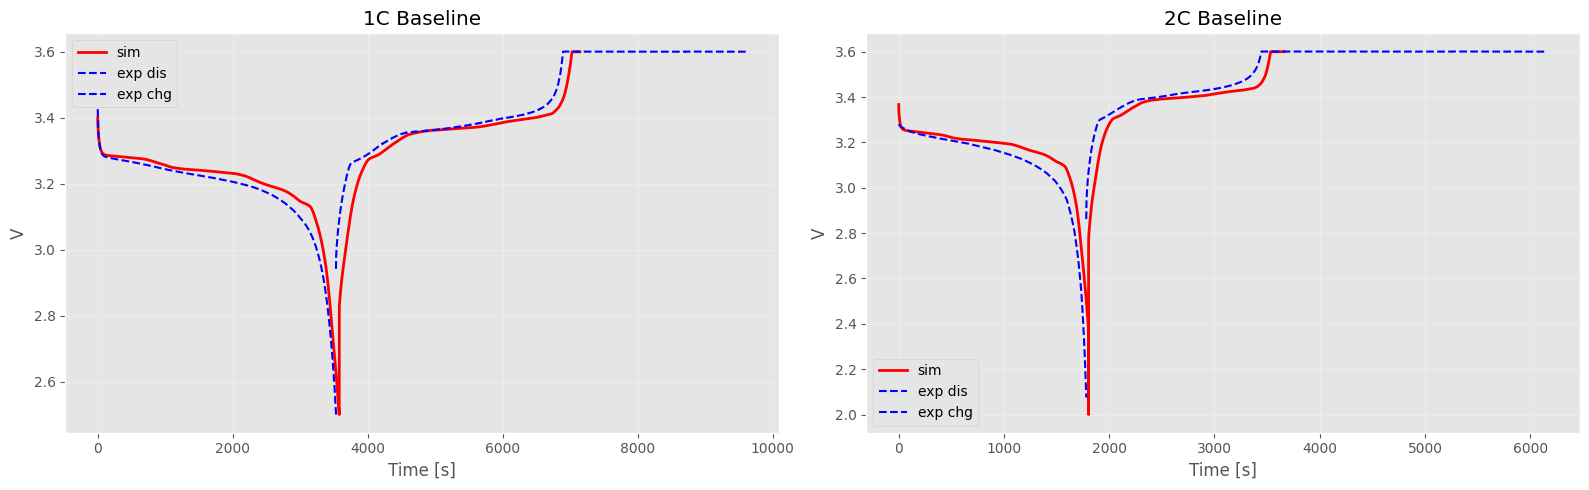

1C: Q_dis=0.077 Ah
2C: Q_dis=0.077 Ah


In [20]:
base_1C = run_cycle(build_baseline(), "1C", "Baseline 1C")
base_2C = run_cycle(build_baseline(), "2C", "Baseline 2C")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
if base_1C:
    ax1.plot(base_1C['t'], base_1C['V'], 'r-', lw=2, label='sim')
    if '1D' in exp and '1C' in exp:
        ax1.plot(exp['1D']['t'], exp['1D']['V'], 'b--', label='exp dis')
        ax1.plot(exp['1C']['t']+3530, exp['1C']['V'], 'b--', label='exp chg')
    ax1.set_title('1C Baseline'); ax1.set_xlabel('Time [s]'); ax1.set_ylabel('V')
    ax1.legend(); ax1.grid(True, alpha=0.3)

if base_2C:
    ax2.plot(base_2C['t'], base_2C['V'], 'r-', lw=2, label='sim')
    if '2D' in exp and '2C' in exp:
        ax2.plot(exp['2D']['t'], exp['2D']['V'], 'b--', label='exp dis')
        ax2.plot(exp['2C']['t']+1782, exp['2C']['V'], 'b--', label='exp chg')
    ax2.set_title('2C Baseline'); ax2.set_xlabel('Time [s]'); ax2.set_ylabel('V')
    ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"1C: Q_dis={base_1C['Q'][-1]:.3f} Ah" if base_1C else "1C failed")
print(f"2C: Q_dis={base_2C['Q'][-1]:.3f} Ah" if base_2C else "2C failed")

## 6. Define all parameter sweeps

In [7]:
multipliers = [0.1, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
E_mults = [0.01, 0.1, 0.50, 1.0, 2, 5, 10, 100]

scalar_sweeps = {
    "L_neg": ("Negative electrode thickness [m]", 3.63e-05),
    "L_sep": ("Separator thickness [m]", 2.5e-05),
    "L_pos": ("Positive electrode thickness [m]", 6.27e-05),
    "c_s_max_neg": ("Maximum concentration in negative electrode [mol.m-3]", 30985),
    "R_p_neg": ("Negative particle radius [m]", 3e-07),
    "eps_s_neg": ("Negative electrode active material volume fraction", 0.58),
    "eps_e_neg": ("Negative electrode porosity", 0.32),
    "Brugg_neg": ("Negative electrode Bruggeman coefficient (electrolyte)", 2.5),
    "sigma_s_neg": ("Negative electrode conductivity [S.m-1]", 0.5*215.0),
    "c_s_max_pos": ("Maximum concentration in positive electrode [mol.m-3]", 22806),
    "R_p_pos": ("Positive particle radius [m]", 0.75*3.80e-08),
    "sigma_s_pos": ("Positive electrode conductivity [S.m-1]", 0.8),
    "eps_s_pos": ("Positive electrode active material volume fraction", 0.370529),
    "eps_e_pos": ("Positive electrode porosity", 0.55),
    "Brugg_pos": ("Positive electrode Bruggeman coefficient (electrolyte)", 2.5),
    "eps_e_sep": ("Separator porosity", 0.55),
    "Brugg_sep": ("Separator Bruggeman coefficient (electrolyte)", 2.5),
    "c_e_init": ("Initial concentration in electrolyte [mol.m-3]", 1200.0),
    "t_plus": ("Cation transference number", 0.38),
    "TDF": ("Thermodynamic factor", 0.5),
    "h_cool": ("Total heat transfer coefficient [W.m-2.K-1]", 12.0),
    "R_contact": ("Contact resistance [Ohm]", 0.01),
    "x0_neg": ("Initial concentration in negative electrode [mol.m-3]", 0.76*30985),
    "x0_pos": ("Initial concentration in positive electrode [mol.m-3]", 0.01*22882),
}

function_sweeps = {
    "pos_j0_mref":  {"key":"Positive electrode exchange-current density [A.m-2]",  "factory":lambda s:make_pos_j0(m_ref=6e-07*s), "mults":multipliers},
    "pos_j0_Er":    {"key":"Positive electrode exchange-current density [A.m-2]",  "factory":lambda s:make_pos_j0(E_r=39570*s),   "mults":E_mults},
    "neg_j0_mref":  {"key":"Negative electrode exchange-current density [A.m-2]",  "factory":lambda s:make_neg_j0(m_ref=6.48e-05*s),"mults":multipliers},
    "pos_Ds_Dref":  {"key":"Positive particle diffusivity [m2.s-1]",              "factory":lambda s:make_pos_Ds(D_ref=1.35e-17*s),"mults":multipliers},
    "pos_Ds_ED":    {"key":"Positive particle diffusivity [m2.s-1]",              "factory":lambda s:make_pos_Ds(E_D=39000*s),     "mults":E_mults},
    "neg_Ds_Dref":  {"key":"Negative particle diffusivity [m2.s-1]",              "factory":lambda s:make_neg_Ds(D_ref=2.4e-13*s), "mults":multipliers},
    "kappa_scale":  {"key":"Electrolyte conductivity [S.m-1]",                    "factory":lambda s:make_elyte_cond(scale=s),      "mults":multipliers},
    "kappa_Ek":     {"key":"Electrolyte conductivity [S.m-1]",                    "factory":lambda s:make_elyte_cond(E_k=2.7771e4*s),"mults":E_mults},
    "OCP_v0":       {"key":"Positive electrode OCP [V]",                          "factory":lambda s:make_lfp_ocp(v0=3.4297+0.02*(s-1)),"mults":[0.5,0.8,1.0,1.2,1.5,2.0]},
    "OCP_lith_v0":  {"key":"Positive electrode lithiation OCP [V]",               "factory":lambda s:make_lfp_ocp_lith(v0=3.4097+0.02*(s-1)),"mults":[0.5,0.8,1.0,1.2,1.5,2.0]},
}

n_total = (len(scalar_sweeps)*len(multipliers) + sum(len(v["mults"]) for v in function_sweeps.values())) * 2
print(f"{len(scalar_sweeps)} scalar + {len(function_sweeps)} function sweeps")
print(f"~{n_total} total simulations (×2 protocols)")

24 scalar + 10 function sweeps
~478 total simulations (×2 protocols)


## 7. Run all sweeps (1C and 2C)

In [8]:
all_results = {}  # {param_name: {"1C": [...], "2C": [...]}}

# Scalar sweeps
for name, (key, base_val) in scalar_sweeps.items():
    print(f"\n--- {name} ---")
    all_results[name] = {"1C": [], "2C": []}
    for mult in multipliers:
        new_val = base_val * mult
        if "porosity" in key.lower() and new_val > 0.95: continue
        if "transference" in key.lower() and new_val > 0.95: continue
        for proto in ["1C", "2C"]:
            p = build_baseline()
            p[key] = new_val
            res = run_cycle(p, proto, f"{name}={mult:.1f}x [{proto}]")
            if res:
                res['mult'] = mult
                all_results[name][proto].append(res)
        print(f"  {mult:.1f}x done")

# Function sweeps
for name, spec in function_sweeps.items():
    print(f"\n--- {name} ---")
    all_results[name] = {"1C": [], "2C": []}
    for mult in spec["mults"]:
        for proto in ["1C", "2C"]:
            p = build_baseline()
            p[spec["key"]] = spec["factory"](mult)
            res = run_cycle(p, proto, f"{name}={mult:.2f}x [{proto}]")
            if res:
                res['mult'] = mult
                all_results[name][proto].append(res)
        print(f"  {mult:.2f}x done")

print(f"\n=== All sweeps complete. {len(all_results)} parameters swept. ===")


--- L_neg ---
  0.1x done
  0.5x done
  0.8x done
  1.0x done
  1.2x done
  1.5x done
  2.0x done

--- L_sep ---
  0.1x done
  0.5x done
  0.8x done
  1.0x done
  1.2x done
  1.5x done
  2.0x done

--- L_pos ---
  0.1x done
  0.5x done
  0.8x done
  1.0x done
  1.2x done
  1.5x done
  2.0x done

--- c_s_max_neg ---


2026-04-13 23:39:46.051 - [ERROR] callbacks.on_experiment_error(235): Simulation error: Events ['Maximum voltage [V]'] are non-positive at initial conditions


  FAILED [c_s_max_neg=0.1x [1C]]: Events ['Maximum voltage [V]'] are non-positive at initial conditions


2026-04-13 23:39:52.046 - [ERROR] callbacks.on_experiment_error(235): Simulation error: Events ['Maximum voltage [V]'] are non-positive at initial conditions


  FAILED [c_s_max_neg=0.1x [2C]]: Events ['Maximum voltage [V]'] are non-positive at initial conditions
  0.1x done


...

  FAILED [pos_Ds_ED=100.00x [2C]]: FAILURE IDA_CONV_FAIL: Convergence test failures occurred too many times during one internal time step or minimum step size was reached.
  100.00x done

--- neg_Ds_Dref ---
  0.10x done
  0.50x done
  0.80x done
  1.00x done
  1.20x done
  1.50x done
  2.00x done

--- kappa_scale ---
  0.10x done
  0.50x done
  0.80x done
  1.00x done
  1.20x done
  1.50x done
  2.00x done

--- kappa_Ek ---
  0.01x done
  0.10x done
  0.50x done
  1.00x done
  2.00x done
  5.00x done
  10.00x done


2026-04-14 00:50:05.776 - [ERROR] callbacks.on_experiment_error(235): Simulation error: Could not find consistent states: Could not find acceptable solution: solver returned NaNs or Infs


  FAILED [kappa_Ek=100.00x [1C]]: Could not find consistent states: Could not find acceptable solution: solver returned NaNs or Infs


2026-04-14 00:50:08.203 - [ERROR] callbacks.on_experiment_error(235): Simulation error: Could not find consistent states: Could not find acceptable solution: solver returned NaNs or Infs


  FAILED [kappa_Ek=100.00x [2C]]: Could not find consistent states: Could not find acceptable solution: solver returned NaNs or Infs
  100.00x done

--- OCP_v0 ---
  0.50x done
  0.80x done
  1.00x done
  1.20x done
  1.50x done
  2.00x done

--- OCP_lith_v0 ---
  0.50x done
  0.80x done
  1.00x done
  1.20x done
  1.50x done
  2.00x done

=== All sweeps complete. 34 parameters swept. ===


## 8. Sensitivity plots — 1C (V vs Time with experimental overlay)

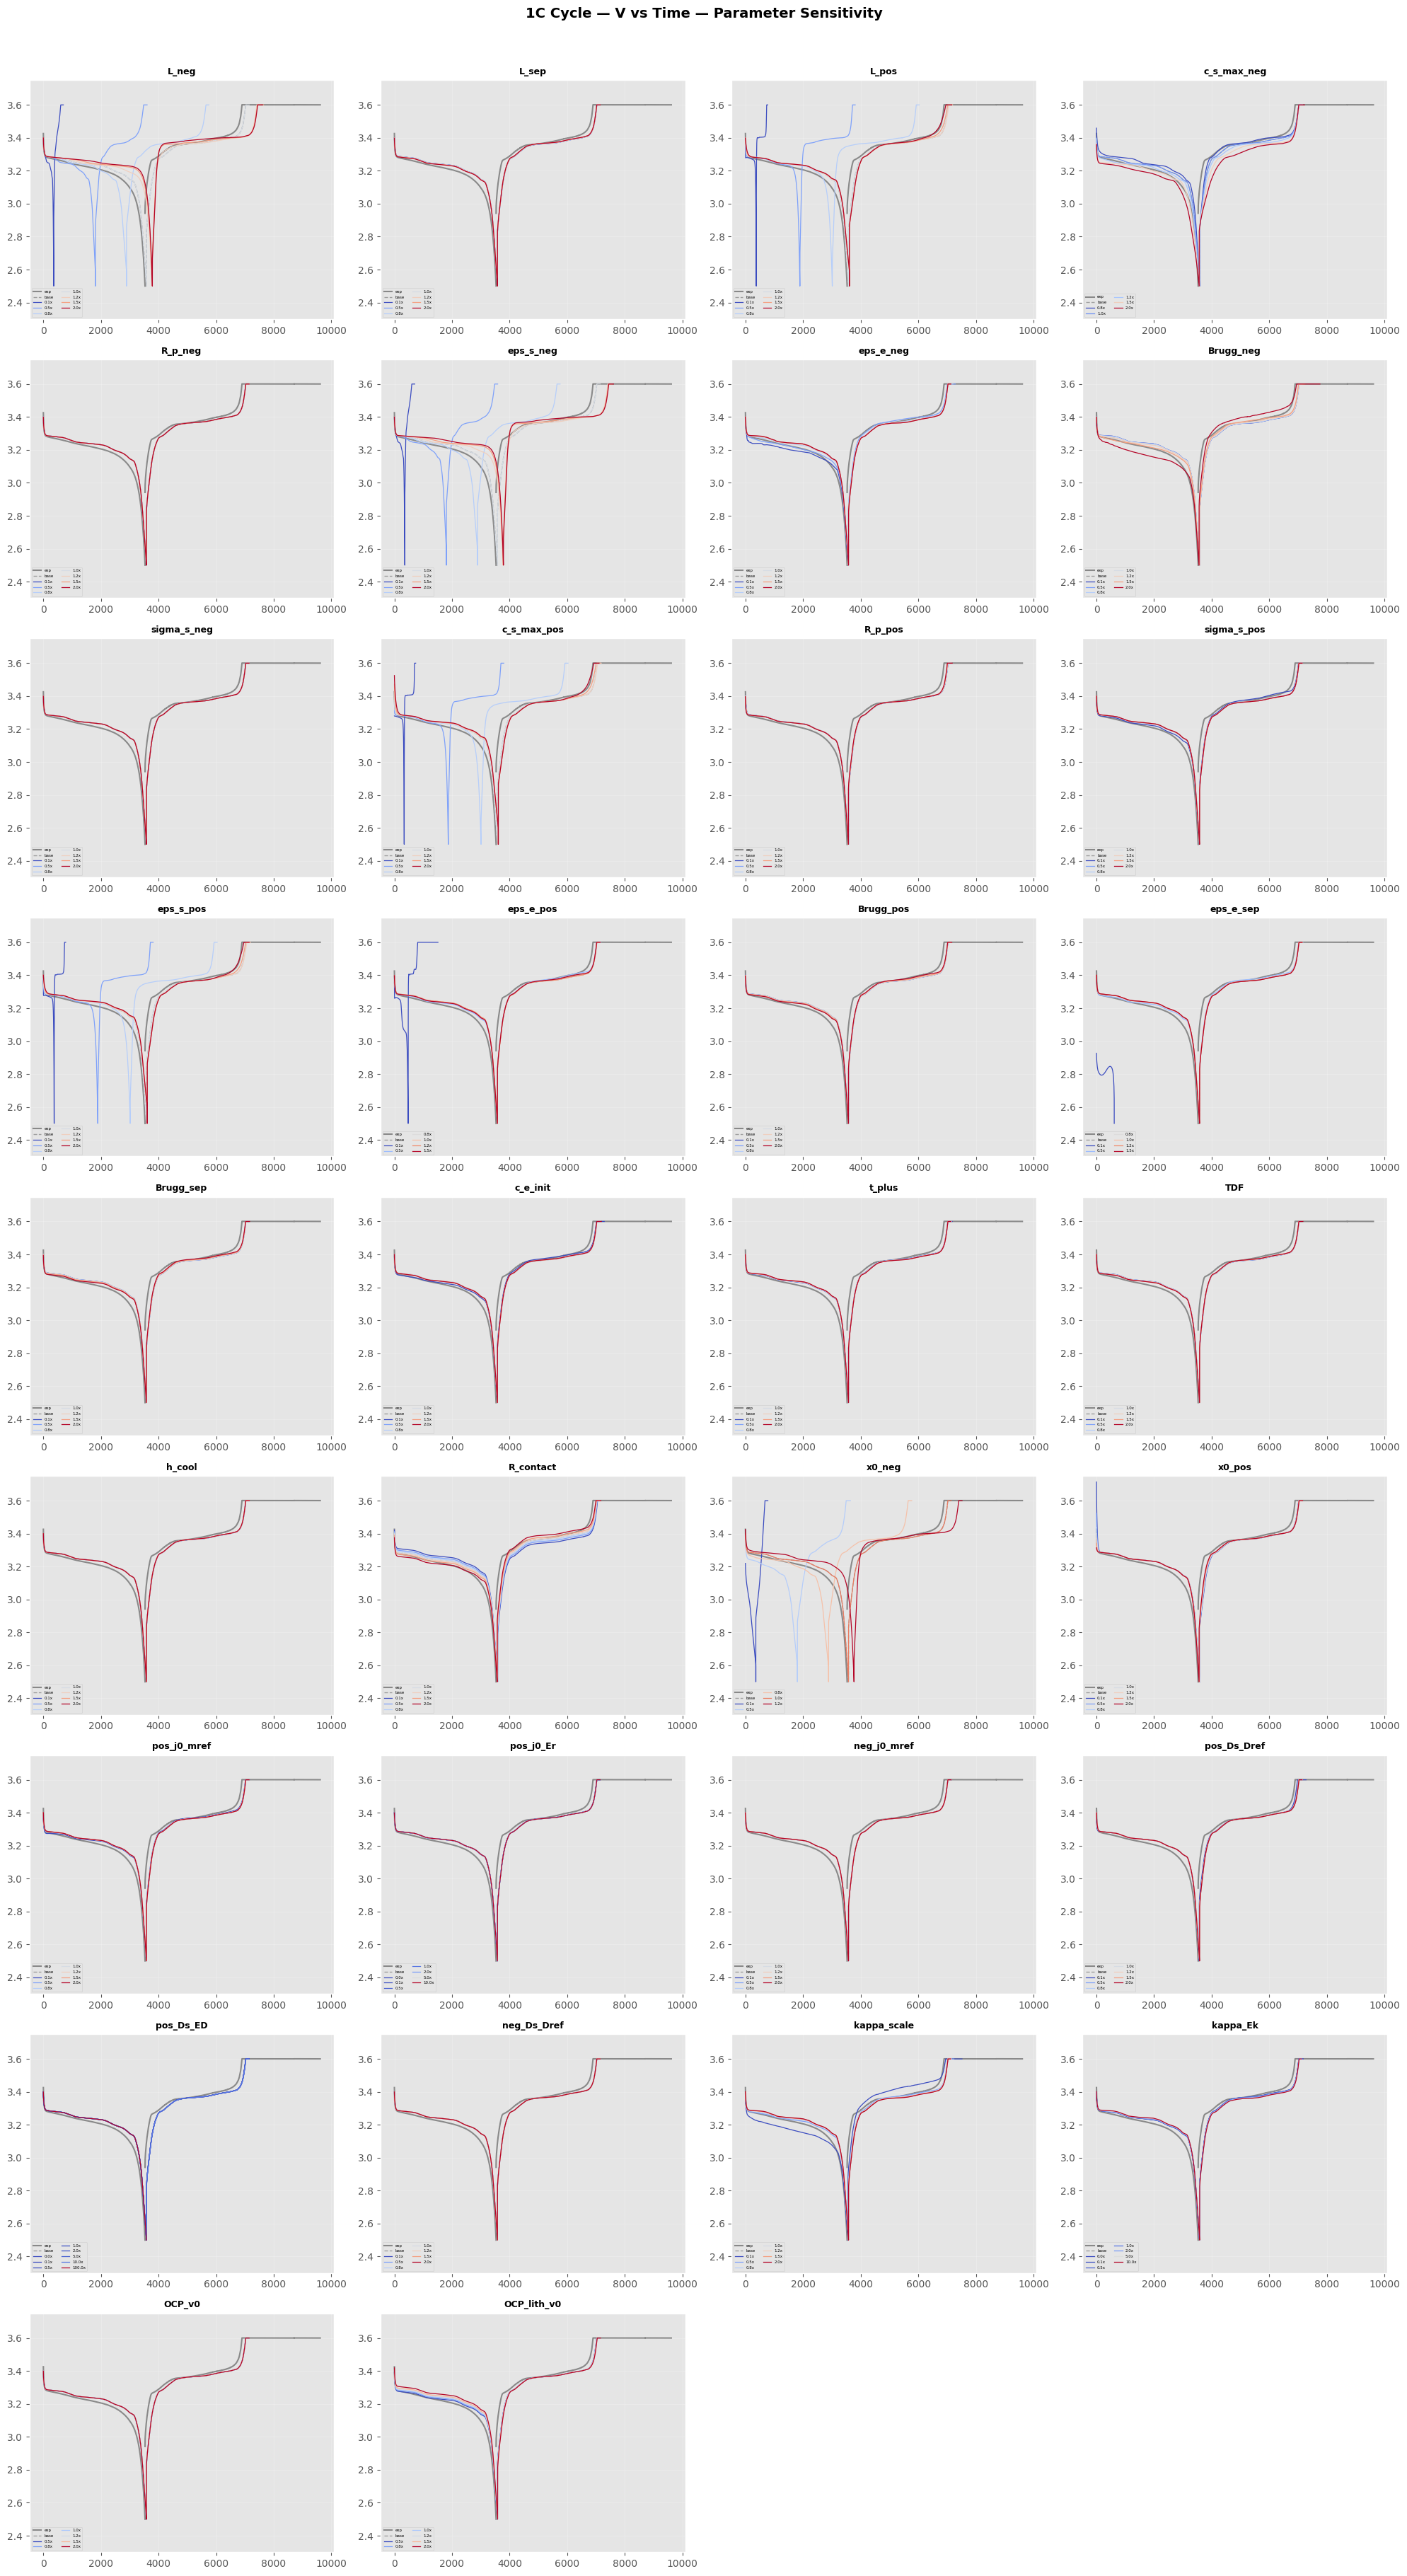

In [9]:
names = list(all_results.keys())
n = len(names)
ncols, nrows = 4, int(np.ceil(n/4))
cmap = plt.cm.coolwarm

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for idx, name in enumerate(names):
    ax = axes[idx]
    runs = all_results[name]["1C"]
    if not runs: continue
    mults = [r['mult'] for r in runs]
    norm = plt.Normalize(min(mults), max(mults))

    # Experimental data
    if '1D' in exp and '1C' in exp:
        ax.plot(exp['1D']['t'], exp['1D']['V'], 'k-', lw=1.5, alpha=0.4, label='exp')
        ax.plot(exp['1C']['t']+3530, exp['1C']['V'], 'k-', lw=1.5, alpha=0.4)

    # Baseline
    if base_1C:
        ax.plot(base_1C['t'], base_1C['V'], 'k--', lw=1, alpha=0.3, label='base')

    for r in runs:
        ax.plot(r['t'], r['V'], color=cmap(norm(r['mult'])), lw=0.9, label=f"{r['mult']:.1f}x")

    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylim([2.3, 3.75]); ax.grid(True, alpha=0.2)
    ax.legend(fontsize=4, loc='lower left', ncol=2)

for idx in range(n, len(axes)): fig.delaxes(axes[idx])
fig.suptitle('1C Cycle — V vs Time — Parameter Sensitivity', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('sens_1C_Vvst.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Sensitivity plots — 2C (V vs Time with experimental overlay)

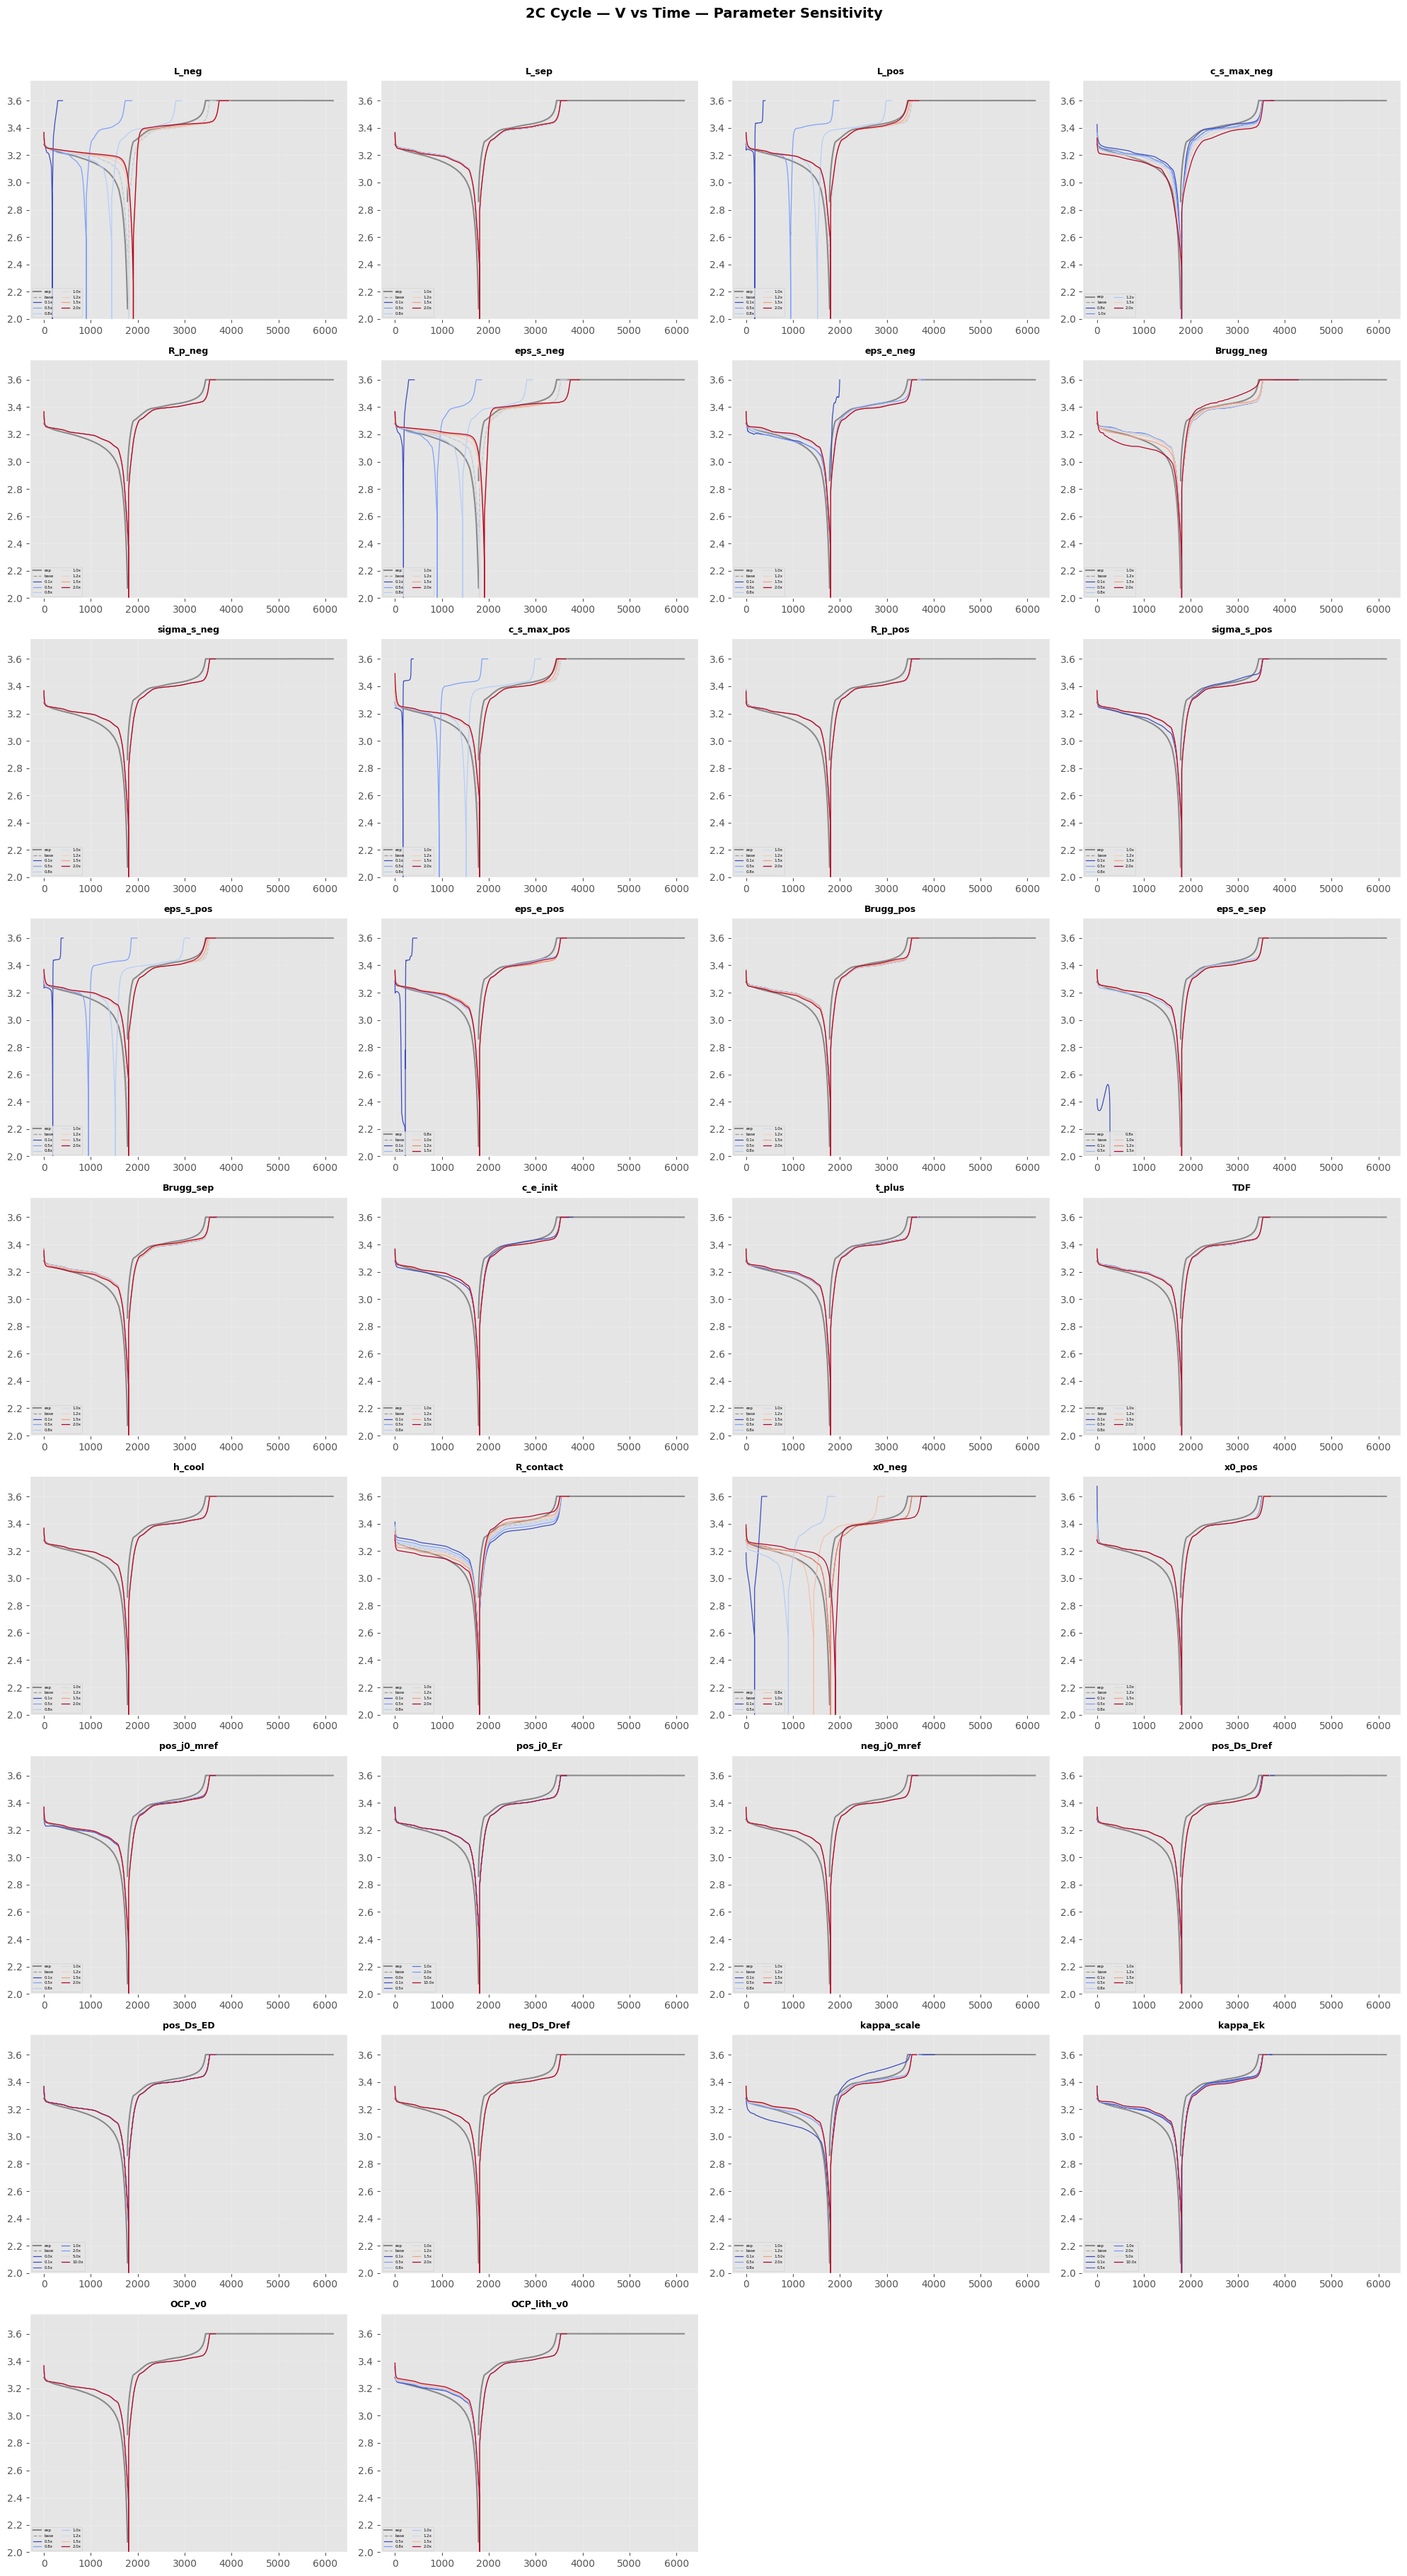

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for idx, name in enumerate(names):
    ax = axes[idx]
    runs = all_results[name]["2C"]
    if not runs: continue
    mults = [r['mult'] for r in runs]
    norm = plt.Normalize(min(mults), max(mults))

    if '2D' in exp and '2C' in exp:
        ax.plot(exp['2D']['t'], exp['2D']['V'], 'k-', lw=1.5, alpha=0.4, label='exp')
        ax.plot(exp['2C']['t']+1782, exp['2C']['V'], 'k-', lw=1.5, alpha=0.4)

    if base_2C:
        ax.plot(base_2C['t'], base_2C['V'], 'k--', lw=1, alpha=0.3, label='base')

    for r in runs:
        ax.plot(r['t'], r['V'], color=cmap(norm(r['mult'])), lw=0.9, label=f"{r['mult']:.1f}x")

    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_ylim([2.0, 3.75]); ax.grid(True, alpha=0.2)
    ax.legend(fontsize=4, loc='lower left', ncol=2)

for idx in range(n, len(axes)): fig.delaxes(axes[idx])
fig.suptitle('2C Cycle — V vs Time — Parameter Sensitivity', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('sens_2C_Vvst.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Tornado chart — RMSE vs experimental (1C)

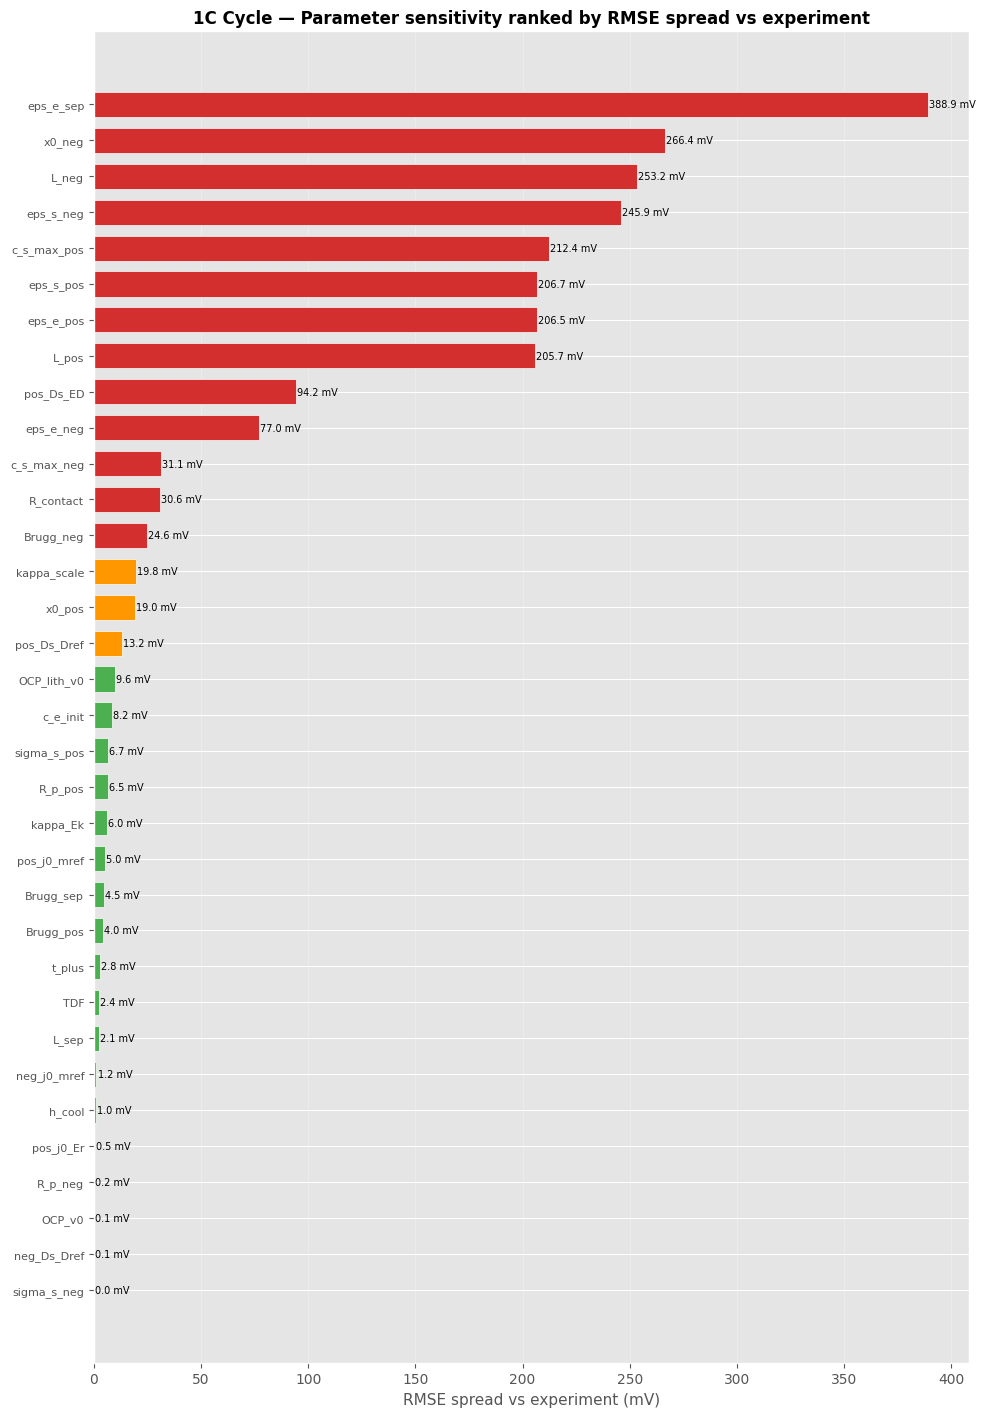


TOP 10 MOST SENSITIVE (1C RMSE):
  1. eps_e_sep: spread=388.9 mV, RMSE range=[72.4, 461.3] mV
  2. x0_neg: spread=266.4 mV, RMSE range=[77.6, 344.0] mV
  3. L_neg: spread=253.2 mV, RMSE range=[77.6, 330.8] mV
  4. eps_s_neg: spread=245.9 mV, RMSE range=[77.6, 323.5] mV
  5. c_s_max_pos: spread=212.4 mV, RMSE range=[77.6, 290.0] mV
  6. eps_s_pos: spread=206.7 mV, RMSE range=[77.6, 284.3] mV
  7. eps_e_pos: spread=206.5 mV, RMSE range=[73.7, 280.2] mV
  8. L_pos: spread=205.7 mV, RMSE range=[77.6, 283.2] mV
  9. pos_Ds_ED: spread=94.2 mV, RMSE range=[76.8, 171.0] mV
  10. eps_e_neg: spread=77.0 mV, RMSE range=[67.4, 144.4] mV


In [11]:
def rmse_vs_exp(sim_t, sim_V, exp_t, exp_V):
    """Interpolate sim onto exp time grid and compute RMSE."""
    V_interp = np.interp(exp_t, sim_t, sim_V, left=np.nan, right=np.nan)
    mask = ~np.isnan(V_interp)
    if mask.sum() < 10: return np.nan
    return np.sqrt(np.mean((V_interp[mask] - exp_V[mask])**2))

# Build experimental time/voltage for full 1C cycle
if '1D' in exp and '1C' in exp:
    t_exp_1C = np.concatenate([exp['1D']['t'].values, exp['1C']['t'].values + 3530])
    V_exp_1C = np.concatenate([exp['1D']['V'].values, exp['1C']['V'].values])
else:
    t_exp_1C, V_exp_1C = None, None

if '2D' in exp and '2C' in exp:
    t_exp_2C = np.concatenate([exp['2D']['t'].values, exp['2C']['t'].values + 1782])
    V_exp_2C = np.concatenate([exp['2D']['V'].values, exp['2C']['V'].values])
else:
    t_exp_2C, V_exp_2C = None, None

sensitivities = []
for name in all_results:
    rmse_list = []
    for r in all_results[name]["1C"]:
        if t_exp_1C is not None:
            rmse_list.append(rmse_vs_exp(r['t'], r['V'], t_exp_1C, V_exp_1C))
    rmse_list = [x for x in rmse_list if not np.isnan(x)]
    if len(rmse_list) >= 2:
        spread = max(rmse_list) - min(rmse_list)
        sensitivities.append((name, spread*1000, min(rmse_list)*1000, max(rmse_list)*1000))

sensitivities.sort(key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(sensitivities)*0.42)))
y_pos = range(len(sensitivities))
spreads = [s[1] for s in sensitivities]
colors = ['#d32f2f' if s>20 else '#ff9800' if s>10 else '#4caf50' for s in spreads]
bars = ax.barh(y_pos, spreads, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(y_pos); ax.set_yticklabels([s[0] for s in sensitivities], fontsize=8)
ax.set_xlabel('RMSE spread vs experiment (mV)', fontsize=11)
ax.set_title('1C Cycle — Parameter sensitivity ranked by RMSE spread vs experiment', fontsize=12, fontweight='bold')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
for bar, sp in zip(bars, spreads):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{sp:.1f} mV', va='center', fontsize=7)
plt.tight_layout(); plt.savefig('sens_tornado_rmse.png', dpi=150, bbox_inches='tight'); plt.show()

print("\nTOP 10 MOST SENSITIVE (1C RMSE):")
for i,(name,sp,rmin,rmax) in enumerate(sensitivities[:10]):
    print(f"  {i+1}. {name}: spread={sp:.1f} mV, RMSE range=[{rmin:.1f}, {rmax:.1f}] mV")

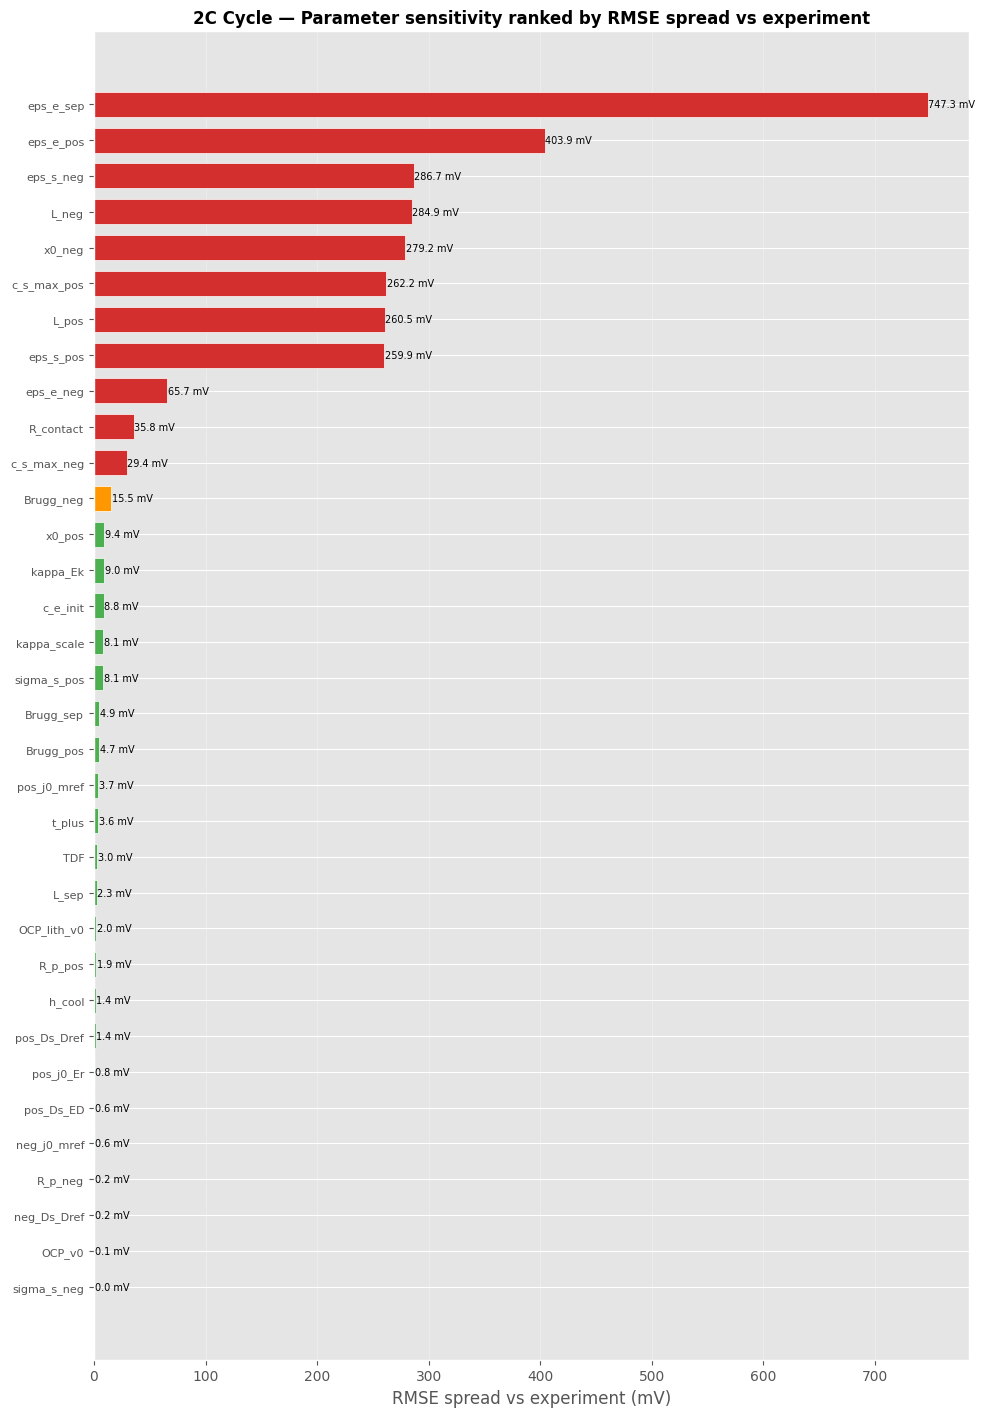


TOP 10 MOST SENSITIVE (2C RMSE):
  1. eps_e_sep: spread=747.3 mV, RMSE range=[84.5, 831.8] mV
  2. eps_e_pos: spread=403.9 mV, RMSE range=[84.6, 488.5] mV
  3. eps_s_neg: spread=286.7 mV, RMSE range=[89.4, 376.1] mV
  4. L_neg: spread=284.9 mV, RMSE range=[89.4, 374.3] mV
  5. x0_neg: spread=279.2 mV, RMSE range=[89.4, 368.6] mV
  6. c_s_max_pos: spread=262.2 mV, RMSE range=[76.3, 338.4] mV
  7. L_pos: spread=260.5 mV, RMSE range=[73.7, 334.2] mV
  8. eps_s_pos: spread=259.9 mV, RMSE range=[75.7, 335.6] mV
  9. eps_e_neg: spread=65.7 mV, RMSE range=[80.0, 145.8] mV
  10. R_contact: spread=35.8 mV, RMSE range=[79.2, 115.0] mV


In [12]:
sensitivities_2C = []
for name in all_results:
    rmse_list = []
    for r in all_results[name]["2C"]:
        if t_exp_2C is not None:
            rmse_list.append(rmse_vs_exp(r['t'], r['V'], t_exp_2C, V_exp_2C))
    rmse_list = [x for x in rmse_list if not np.isnan(x)]
    if len(rmse_list) >= 2:
        spread = max(rmse_list) - min(rmse_list)
        sensitivities_2C.append((name, spread*1000, min(rmse_list)*1000, max(rmse_list)*1000))

sensitivities_2C.sort(key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(sensitivities_2C)*0.42)))
y_pos = range(len(sensitivities_2C))
spreads = [s[1] for s in sensitivities_2C]
colors = ['#d32f2f' if s>20 else '#ff9800' if s>10 else '#4caf50' for s in spreads]
bars = ax.barh(y_pos, spreads, color=colors, edgecolor='white', height=0.7)
ax.set_yticks(y_pos); ax.set_yticklabels([s[0] for s in sensitivities_2C], fontsize=8)
ax.set_xlabel('RMSE spread vs experiment (mV)')
ax.set_title('2C Cycle — Parameter sensitivity ranked by RMSE spread vs experiment', fontsize=12, fontweight='bold')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
for bar, sp in zip(bars, spreads):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{sp:.1f} mV', va='center', fontsize=7)
plt.tight_layout(); plt.savefig('sens_tornado_2C_rmse.png', dpi=150, bbox_inches='tight'); plt.show()

print("\nTOP 10 MOST SENSITIVE (2C RMSE):")
for i,(name,sp,rmin,rmax) in enumerate(sensitivities_2C[:10]):
    print(f"  {i+1}. {name}: spread={sp:.1f} mV, RMSE range=[{rmin:.1f}, {rmax:.1f}] mV")

## 11. Summary

In [13]:
print(f"{'Parameter':<20} {'1C spread(mV)':<15} {'2C spread(mV)':<15} {'Impact'}")
print("="*60)
s1 = {s[0]:s[1] for s in sensitivities}
s2 = {s[0]:s[1] for s in sensitivities_2C}
all_names = list(dict.fromkeys([s[0] for s in sensitivities] + [s[0] for s in sensitivities_2C]))
for name in all_names:
    v1 = s1.get(name, 0); v2 = s2.get(name, 0)
    mx = max(v1, v2)
    tag = "HIGH" if mx > 20 else "MED" if mx > 10 else "low"
    print(f"{name:<20} {v1:<15.1f} {v2:<15.1f} {tag}")

Parameter            1C spread(mV)   2C spread(mV)   Impact
eps_e_sep            388.9           747.3           HIGH
x0_neg               266.4           279.2           HIGH
L_neg                253.2           284.9           HIGH
eps_s_neg            245.9           286.7           HIGH
c_s_max_pos          212.4           262.2           HIGH
eps_s_pos            206.7           259.9           HIGH
eps_e_pos            206.5           403.9           HIGH
L_pos                205.7           260.5           HIGH
pos_Ds_ED            94.2            0.6             HIGH
eps_e_neg            77.0            65.7            HIGH
c_s_max_neg          31.1            29.4            HIGH
R_contact            30.6            35.8            HIGH
Brugg_neg            24.6            15.5            HIGH
kappa_scale          19.8            8.1             MED
x0_pos               19.0            9.4             MED
pos_Ds_Dref          13.2            1.4             MED
OCP_lith_v0    